# HW 3: STFT, Features, and Regression (15 points)

For each markdown cell, add a cell (or cells) of code below. 
Reminders:
* This is an individual assignment. 
* If you use GenAI tools to assist you with your homework, remember to fill out the GenAI Usage Statement at the bottom of the notebook. Even if you use GenAI, you should not be directly copying the code.
* You may only use functions/packages we have discussed in class

In [274]:
# General
from scipy.io.wavfile import read
import numpy as np
from numpy.fft import fft
import matplotlib.pyplot as plt
from IPython.display import Audio

# Feature extraction
import librosa
from librosa import feature

# Regression
from sklearn import preprocessing
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import pandas as pd
import seaborn as sns

Read in the following files from your "audio" folder.
- /audio/country.00000.wav
- /audio/hiphop.00000.wav
    
Ensure that amplitudes are normalized to between -1 and 1. 

fs_country 22050


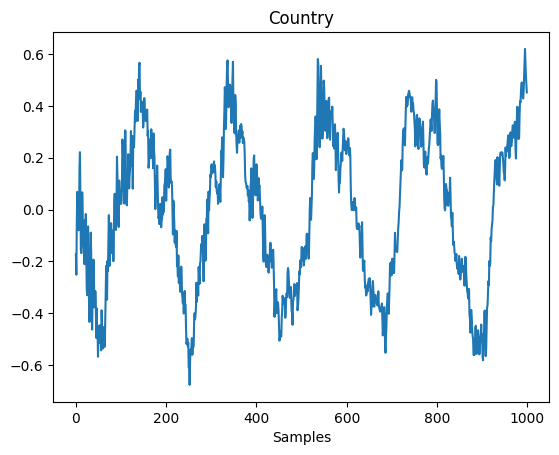

In [275]:
def normalize(file):
    return file/np.max(np.abs(file))

fs_country, country = read("../audio/country.00000.wav")
fs_hiphop, hiphop = read("../audio/hiphop.00000.wav")

country, hiphop = normalize(country), normalize(hiphop)
plt.plot(country[:1000])
plt.title("Country")
plt.xlabel("Samples")
print(f"fs_country {fs_country}")
Audio(country, rate=fs_country)

fs_hiphop 22050


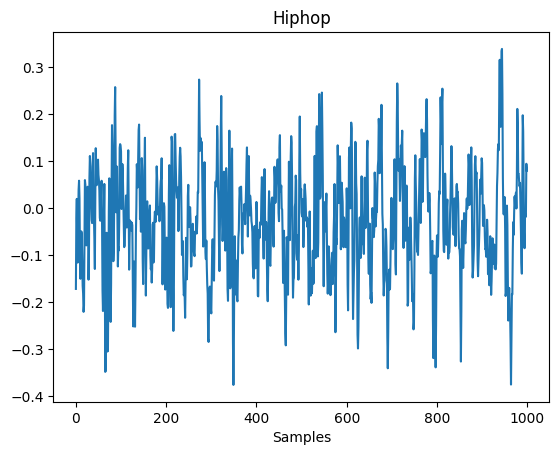

In [276]:
plt.plot(hiphop[:1000])
plt.title("Hiphop")
plt.xlabel("Samples")
print(f"fs_hiphop {fs_hiphop}")
Audio(hiphop, rate=fs_hiphop)

## Part 1: STFT parameters and visualization (6 points)

#### Write your own STFT (3 points)

Write your own STFT function that will output a 2D matrix with shape (num_frames, num_bins), where each row contains the DFT of a single frame.

* Use a hop size equal to half the frame size (i.e., hop_size = frame_size // 2) so that frames overlap by 50%, and you should apply a hanning window to each frame (you may use `np.hanning()` for this.)

* The user should be able to vary the size of the frame (leave hop_size fixed at 50%).

*Note: You should use the built in numpy FFT function (instead of your DFT). This means you will have to work in powers of 2!*

In [277]:
def nextPowerOfTwo(number):
    # Returns next power of two following 'number'
    return 2**(np.ceil(np.log2(number)))

def my_stft(audio_input, frame_size, sampling_rate=44100):
    
    # Define frame_length (should be power of two based on input frame_size)
    frame_length = int(nextPowerOfTwo(frame_size))

    # Define hop size is half the frame size
    hop_length = int(frame_length/2)

    # Define number of frames (m) we can extract with 50% overlap based on the total length of our signal
    # If the signal does not fit an integer number of frames, truncate
    # This calculation is so the mth bin ends at index audio_input.size - 1
    n_mbins = int((audio_input.size - frame_length)/hop_length)

    # Define total number of frequency bins
    n_kbins = int(frame_length) # /2 seems negative phasor included

    # Pre-allocate matrix for STFT. Remember it should be structured as [time_frames, frequency_bins]
    stft_matrix = np.zeros((n_mbins, n_kbins))

    # Define window
    window = np.hanning(frame_length)

    # Iterate through signal by frame
    for m in range(n_mbins):
        # index into the frame, apply window, apply fft over the frame, store in matrix
        frame_start = hop_length * m
        # print(hop_length, frame_start, m, frame_length)
        chunk = audio_input[frame_start : frame_start + frame_length]
        stft_matrix[m] = fft(chunk*window)

    return stft_matrix


#### Apply your STFT function

Apply your STFT function to the audio files listed above (country and hiphop)

In [278]:
# your code here
stft_country = my_stft(country, 60, fs_country)
print(stft_country.shape, stft_country)


/var/folders/vc/cq8t4j_13xl9p07zdyk_n2140000gn/T/ipykernel_19864/3606016364.py:33: ComplexWarning: Casting complex values to real discards the imaginary part
  stft_matrix[m] = fft(chunk*window)


(20726, 64) [[ -8.33164441   4.49358575  -0.27100913 ...   0.21501798  -0.27100913
    4.49358575]
 [-10.66765975   6.33802436  -1.11124766 ...   0.5179981   -1.11124766
    6.33802436]
 [  1.27920892  -1.06240441   0.3049135  ...   0.34912158   0.3049135
   -1.06240441]
 ...
 [ -4.93335081   3.3156898   -1.59190098 ...   1.78864688  -1.59190098
    3.3156898 ]
 [  0.86956857  -1.67992304   0.3919878  ...   2.8694292    0.3919878
   -1.67992304]
 [ -0.26400947   1.72756702  -0.18820415 ...  -3.22924178  -0.18820415
    1.72756702]]


In [279]:
stft_hiphop = my_stft(hiphop, 500, fs_hiphop)
print(stft_hiphop.shape, stft_hiphop)

(2582, 512) [[-8.38655694  4.47309788 -0.09806649 ... -0.44236867 -0.09806649
   4.47309788]
 [-8.1040679   3.83636015  0.49890695 ... -0.14411923  0.49890695
   3.83636015]
 [-5.28373584  1.8927337   1.25462651 ... -0.67070432  1.25462651
   1.8927337 ]
 ...
 [ 7.11714768 -3.38639082 -0.56252806 ...  2.1607567  -0.56252806
  -3.38639082]
 [ 4.62321901 -2.10629298 -0.51386317 ... -0.08437218 -0.51386317
  -2.10629298]
 [-3.75525306  1.89703333 -0.56441803 ... -0.73269231 -0.56441803
   1.89703333]]


/var/folders/vc/cq8t4j_13xl9p07zdyk_n2140000gn/T/ipykernel_19864/3606016364.py:33: ComplexWarning: Casting complex values to real discards the imaginary part
  stft_matrix[m] = fft(chunk*window)


#### Write your own spectrogram function (3 points)

Write your own spectrogram function (using `plt.pcolormesh()`) called `plot_spectrogram()` that takes the complex-valued STFT output from your above function, and the sampling rate, and plots a magnitude spectrogram in decibels.

The axes should be properly labeled (time on x-axis, Frequency on y-axis).

*Note: audio processing workflows and dataframe logic in general in Python commonly use rows = time. However, several plotting functions like pcolormesh() annoyingly expect rows = frequency and columns = time. Therefore, we simply add a step to 'transpose' our 2d array or matrix in our code below.*


Figure(640x480)


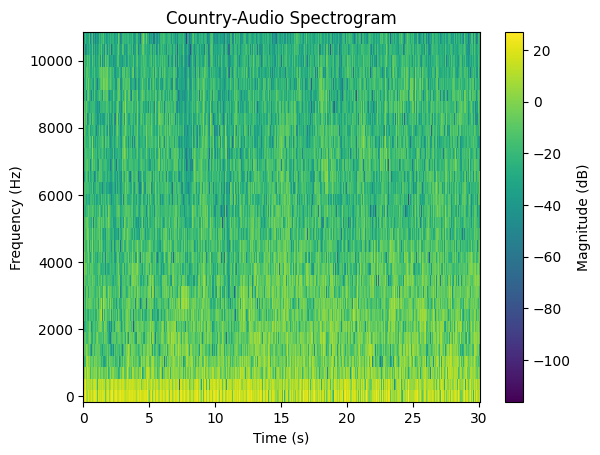

In [280]:
# your code here
def plot_spectrogram(stft_matrix, sampling_rate, title=None):

    # Take magnitude and convert to decibels
    magnitude = np.abs(stft_matrix).T  # Transpose so rows = frequencies
    magnitude_db = 20 * np.log10(magnitude + 1e-6)  # avoid log(0)

    # Time and frequency axes

    # can get frame_length from matrix. Don't need parameter
    # Always N frequency bins from -N/2 to N/2
    num_frames, num_bins = stft_matrix.shape
    frame_length = num_bins
    hop_size = int(frame_length/2)   # recall it was 50% of the frame size
    duration = frame_length / sampling_rate  # find duration (of a frame?)
    # ah if you mean duration of the whole audio, dividing this by the frame assumes non-overlapping frames which is not true.
    
    # Make a time axis by taking the total duration and dividing the timeline according to the number of frames:
    # Each frame has indices [mH, mH + N). corresponding times [mH/fs, (mH+N)/fs]
    time_axis = np.arange(num_frames) * hop_size / sampling_rate
    # Ditto for frequency axis according to the number of bins
    # f = k*fs/N (Hz)
    # same result b/c num bins = frame_length
    freq_axis = np.arange(num_bins) * sampling_rate / frame_length
    nyquist_bin = int(num_bins/2)

    # Plot only up to Nyquist frequency by indexing your magnitude vector
    fig, axs = plt.subplots()
    mesh = axs.pcolormesh(time_axis, freq_axis[:nyquist_bin], magnitude_db[:nyquist_bin,])
    # fig.colorbar()
    axs.set_title(title)
    axs.set_xlabel("Time (s)")
    axs.set_ylabel("Frequency (Hz)")
    cbar = fig.colorbar(mesh)
    cbar.ax.set_ylabel("Magnitude (dB)")
    print(fig)
    
plot_spectrogram(stft_country, fs_country, title="Country-Audio Spectrogram")

Plot the spectrogram of the country and hiphop audio files

(array([[7.74984568e-05, 8.58964348e-05, 3.49260860e-05, ...,
         8.45129847e-05, 3.72560506e-05, 1.80536522e-05],
        [4.48968386e-04, 4.64697563e-04, 4.53069481e-04, ...,
         1.56078371e-04, 1.61143763e-04, 1.29954622e-04],
        [2.37479478e-04, 4.09536366e-04, 1.42667892e-04, ...,
         6.45203178e-06, 2.12478118e-05, 9.82523868e-05],
        ...,
        [9.51376780e-08, 9.77797416e-08, 3.28168662e-08, ...,
         8.88277241e-09, 3.88555681e-09, 2.20392523e-08],
        [4.29466774e-08, 3.86138968e-08, 4.93390912e-08, ...,
         1.77526068e-08, 3.91778658e-10, 1.13459757e-08],
        [7.21121554e-08, 6.27617566e-11, 4.27335757e-11, ...,
         1.03270239e-09, 3.85165360e-09, 6.76893262e-10]]),
 array([    0.       ,    86.1328125,   172.265625 ,   258.3984375,
          344.53125  ,   430.6640625,   516.796875 ,   602.9296875,
          689.0625   ,   775.1953125,   861.328125 ,   947.4609375,
         1033.59375  ,  1119.7265625,  1205.859375 ,  1291.99

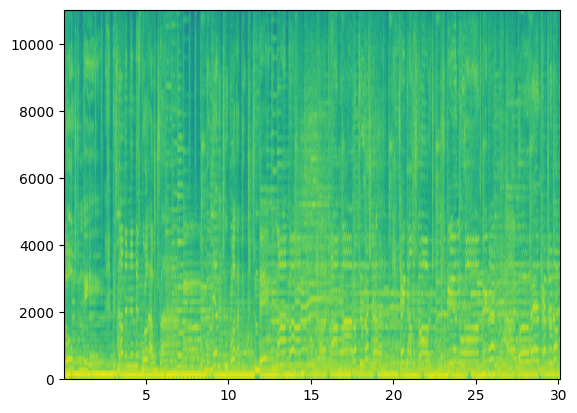

In [281]:
plt.specgram(country, Fs=fs_country)

Figure(640x480)


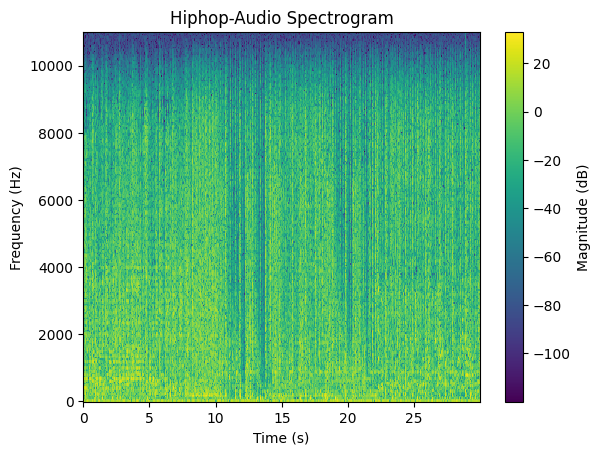

In [282]:
plot_spectrogram(stft_hiphop, fs_hiphop, title="Hiphop-Audio Spectrogram")

## Part 2: Feature Extraction (4 points)

We will perform feature extraction and compare the two audio files above.

Extract the following features for each file (you may use librosa functions):
- RMSE
- Spectral Centroid
- Spectral Flux
- ZCR

For each feature:
- graph the results of each feature
- briefly describe what the feature might tell us perceptually
- briefly describe whether or not this might be a useful feature for classification (based on the graphs)

1 point for each correct feature calculation and associated explanation/reasoning

In [283]:
def graph_feature(feature_func, pass_sr=False, title=None, ylabel=None, ):
    """
    Basic Helper function for graphing the features
    I believe librosa.times_like calculates the start time of each frame
    using t = m * H / fs, m = 0,...num_frames, H: hop_size, fs: sample_rate
    """
    # match kwargs to functions. could expand to including the STFT.
    kwargs = {
        "country" : {},
        "hiphop" : {}
    }
    if pass_sr:
        kwargs["country"]["sr"] = fs_country
        kwargs["hiphop"]["sr"] = fs_hiphop

    title = feature_func.__name__ if title is None else title
    ylabel = title if ylabel is None else ylabel

    feature_country = feature_func(y=country, **kwargs["country"])[0] # 1 channel
    feature_hiphop = feature_func(y=hiphop, **kwargs["hiphop"])[0]

    fig, (ax1, ax2) = plt.subplots(nrows=2)
    ax1.plot(librosa.times_like(feature_country, sr=fs_country), feature_country)
    ax1.set_title(f"{title} country")
    ax1.set_xlabel("time (s)")
    ax1.set_ylabel(ylabel)
    ax2.plot(librosa.times_like(feature_hiphop, sr=fs_hiphop), feature_hiphop)
    ax2.set_title(f"{title} hiphop")
    ax2.set_xlabel("time (s)")
    ax2.set_ylabel(ylabel)
    fig.tight_layout()
    print(fig)

Figure(640x480)


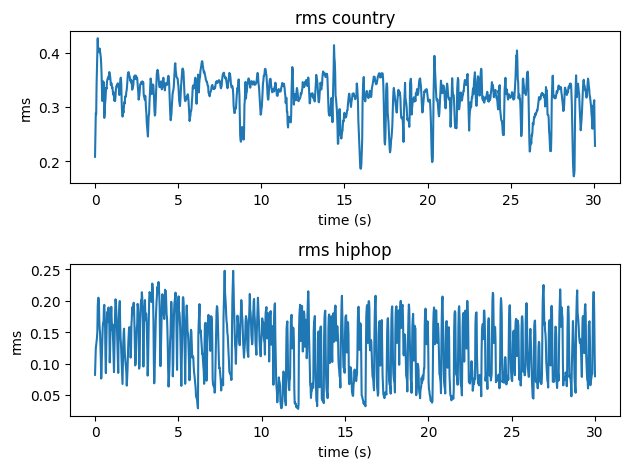

In [284]:
# RMSE
graph_feature(feature.rms)

Your RMSE explantion here!

- RMSE describes the average power of a signal, which is perceptually related to loudness.
- It would be useful for classification because the hiphop rms is a much noisier signal, likely due to the percussion
- Standard deviation might be good.

Figure(640x480)


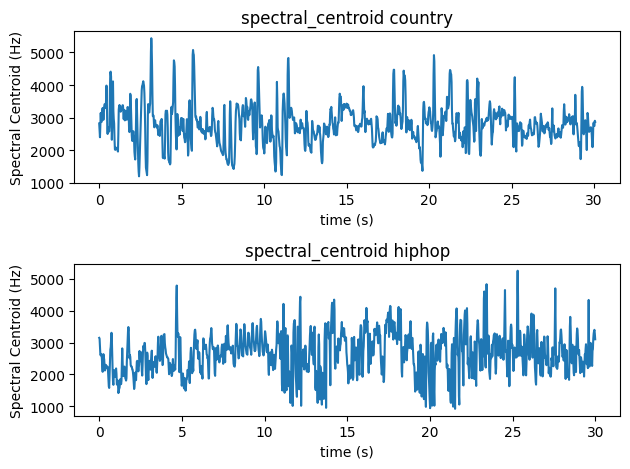

In [285]:
# Spectral Centroid
graph_feature(feature.spectral_centroid, pass_sr=True, ylabel="Spectral Centroid (Hz)")
# note, for more frequency domain features and more data as in project 2, I'll pass in the stft.
# It'd be nice to pass in my stft's, but they don't perfectly fit.

Your centroid explanation here!

- Spectral centroid is like the center of mass of the frequency spectrum. It is a weighted average of the frequency bins by their energy. It's location is related to timbre, and its variance is related to tonality.
- It would not be that useful for classification as the signals are similar.

- Basing function off this formula and notes
$$ SF = \frac{\sqrt{\sum(|X(k,n)| - |X(k,n -1)|)^2}}{k/2} $$

shape: (1025, 1296), sf: [0.20797646 0.10854767 0.10792075 ... 0.34956305 0.20713573 0.16271214], sf.shape: (1295,)
shape: (1025, 1293), sf: [0.08816952 0.08748372 0.07835787 ... 0.17956778 0.14111771 0.09662129], sf.shape: (1292,)
Figure(640x480)


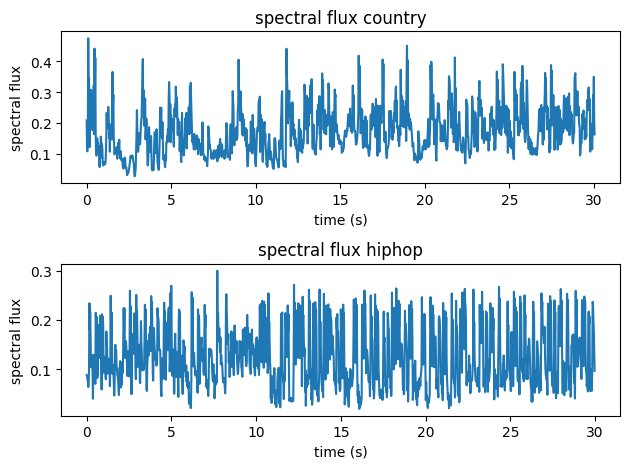

In [286]:
# Spectral Flux
def spectral_flux(y):
    stft = librosa.stft(y)
    magnitude = np.abs(stft) # [f, t]
    # Frame-to-frame difference
    diff = np.diff(magnitude, axis=1)

    # Square and sum across frequency bins
    energy = np.sum(diff**2, axis=0)
    sf = np.sqrt(energy) / (stft.shape[0]/2)
    print(f"shape: {stft.shape}, sf: {sf}, sf.shape: {sf.shape}")
    return [sf] # shortcut to work with grapher

graph_feature(spectral_flux, title="spectral flux")

Your spectral flux explanation here!

- The spectral flux measures the rate of change of the energy in the spectrum with respect to time.
- Perceptually related to timbre and onsets
- The hiphop flux is more varied, similar to the RMS, which could be useful for classification. It might correlate with the RMS or centroid though, in which case, one factor should not be included in the model to avoid colinearity.

Figure(640x480)


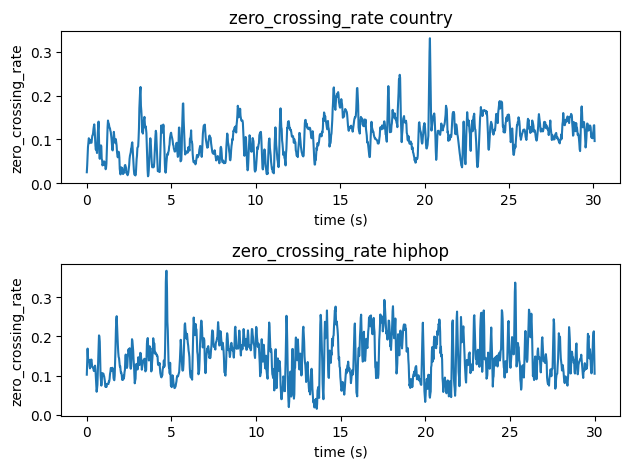

In [287]:
graph_feature(feature.zero_crossing_rate)

Your ZCR explanation here!

- The ZCR is the number of times that the signal changes time in a frame
- It is related to frequency and can be used for rudimentary pitch detection.
- ZCR variance is related to the periodicity of the signal.
- There is slight variation in the ZCR of both signals, but it does not look like it would be optimal for classification.

## Part 3: Binomial Logistic Regression (5 points)

Like in activity 7, you will build a binomial classifier with logistic regression. You will use the GTZAN genre dataset 'features_30_sec.csv' this time to classify hiphop vs country music.

### Explore the data and select your features (3 points)

Use graphing and correlation techniques to determine 5 features you will use for your classification.

You must at a minimum create 1 bar graph and 1 box plot in addition to computing the correlation between the features you select.

Construct your Pandas dataframe for your chosen features. Remember you may want to do some scaling and normalization.

In [288]:
df = pd.read_csv("../Datasets/features_30_sec.csv")
genres = ["country", "hiphop"]
df = df[df["label"].isin(genres)]
df

,filename,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,...,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var,label
200,country.00000.wav,663300,0.384027,0.081182,0.248418,0.000704,2797.844810,354673.043774,2847.551887,105651.317886,...,68.586594,0.615661,54.304928,4.062637,74.334892,0.909476,68.596603,4.095612,73.610832,country
201,country.00001.wav,661760,0.414032,0.079332,0.230516,0.000446,2938.155358,101837.490524,2839.657689,40987.078803,...,37.167381,-2.764677,46.065048,2.824268,48.752991,-1.738780,44.390938,0.974067,48.062492,country
202,country.00002.wav,669680,0.297045,0.097204,0.146586,0.001544,2308.673365,545384.343984,2618.607096,99595.722265,...,37.158360,-4.772855,35.958435,-0.286400,40.287098,-5.357112,43.693214,-1.965473,61.187630,country
203,country.00003.wav,661408,0.376894,0.083747,0.204364,0.001915,2174.033869,570638.884152,2280.888606,207005.343638,...,61.081104,-6.525970,63.754681,-0.034701,47.429501,-1.414051,41.131588,-3.078825,51.753349,country
204,country.00004.wav,661408,0.382781,0.081821,0.209498,0.000802,2966.086095,192897.128750,2848.106749,74510.070234,...,39.297134,-0.166441,43.141171,0.241561,48.237293,-5.440013,33.747955,1.827359,44.118107,country
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,hiphop.00095.wav,661794,0.562447,0.067982,0.103468,0.001790,2735.775141,279951.096596,2295.702995,50878.502151,...,38.174522,-2.969538,43.560001,3.700952,35.976475,-5.405601,34.310566,-4.211085,34.002029,hiphop
496,hiphop.00096.wav,661794,0.424798,0.087508,0.110829,0.001377,1752.626789,162243.481735,1812.043498,69066.703122,...,43.771854,-1.873286,44.473831,-0.149132,36.955051,-2.053678,38.944130,-3.224518,40.173229,hiphop
497,hiphop.00097.wav,661794,0.474049,0.084775,0.118497,0.001741,2582.203954,346817.012357,2526.331057,39700.656524,...,52.881542,-9.132331,45.008186,0.871526,64.853287,-5.987684,71.707214,-0.313200,66.538208,hiphop
498,hiphop.00098.wav,661794,0.533313,0.075971,0.119111,0.002180,2538.747388,305577.006646,2341.475858,48954.857461,...,48.614044,-2.418374,57.909615,1.619183,45.433891,-5.974227,60.627327,-0.824378,64.241043,hiphop


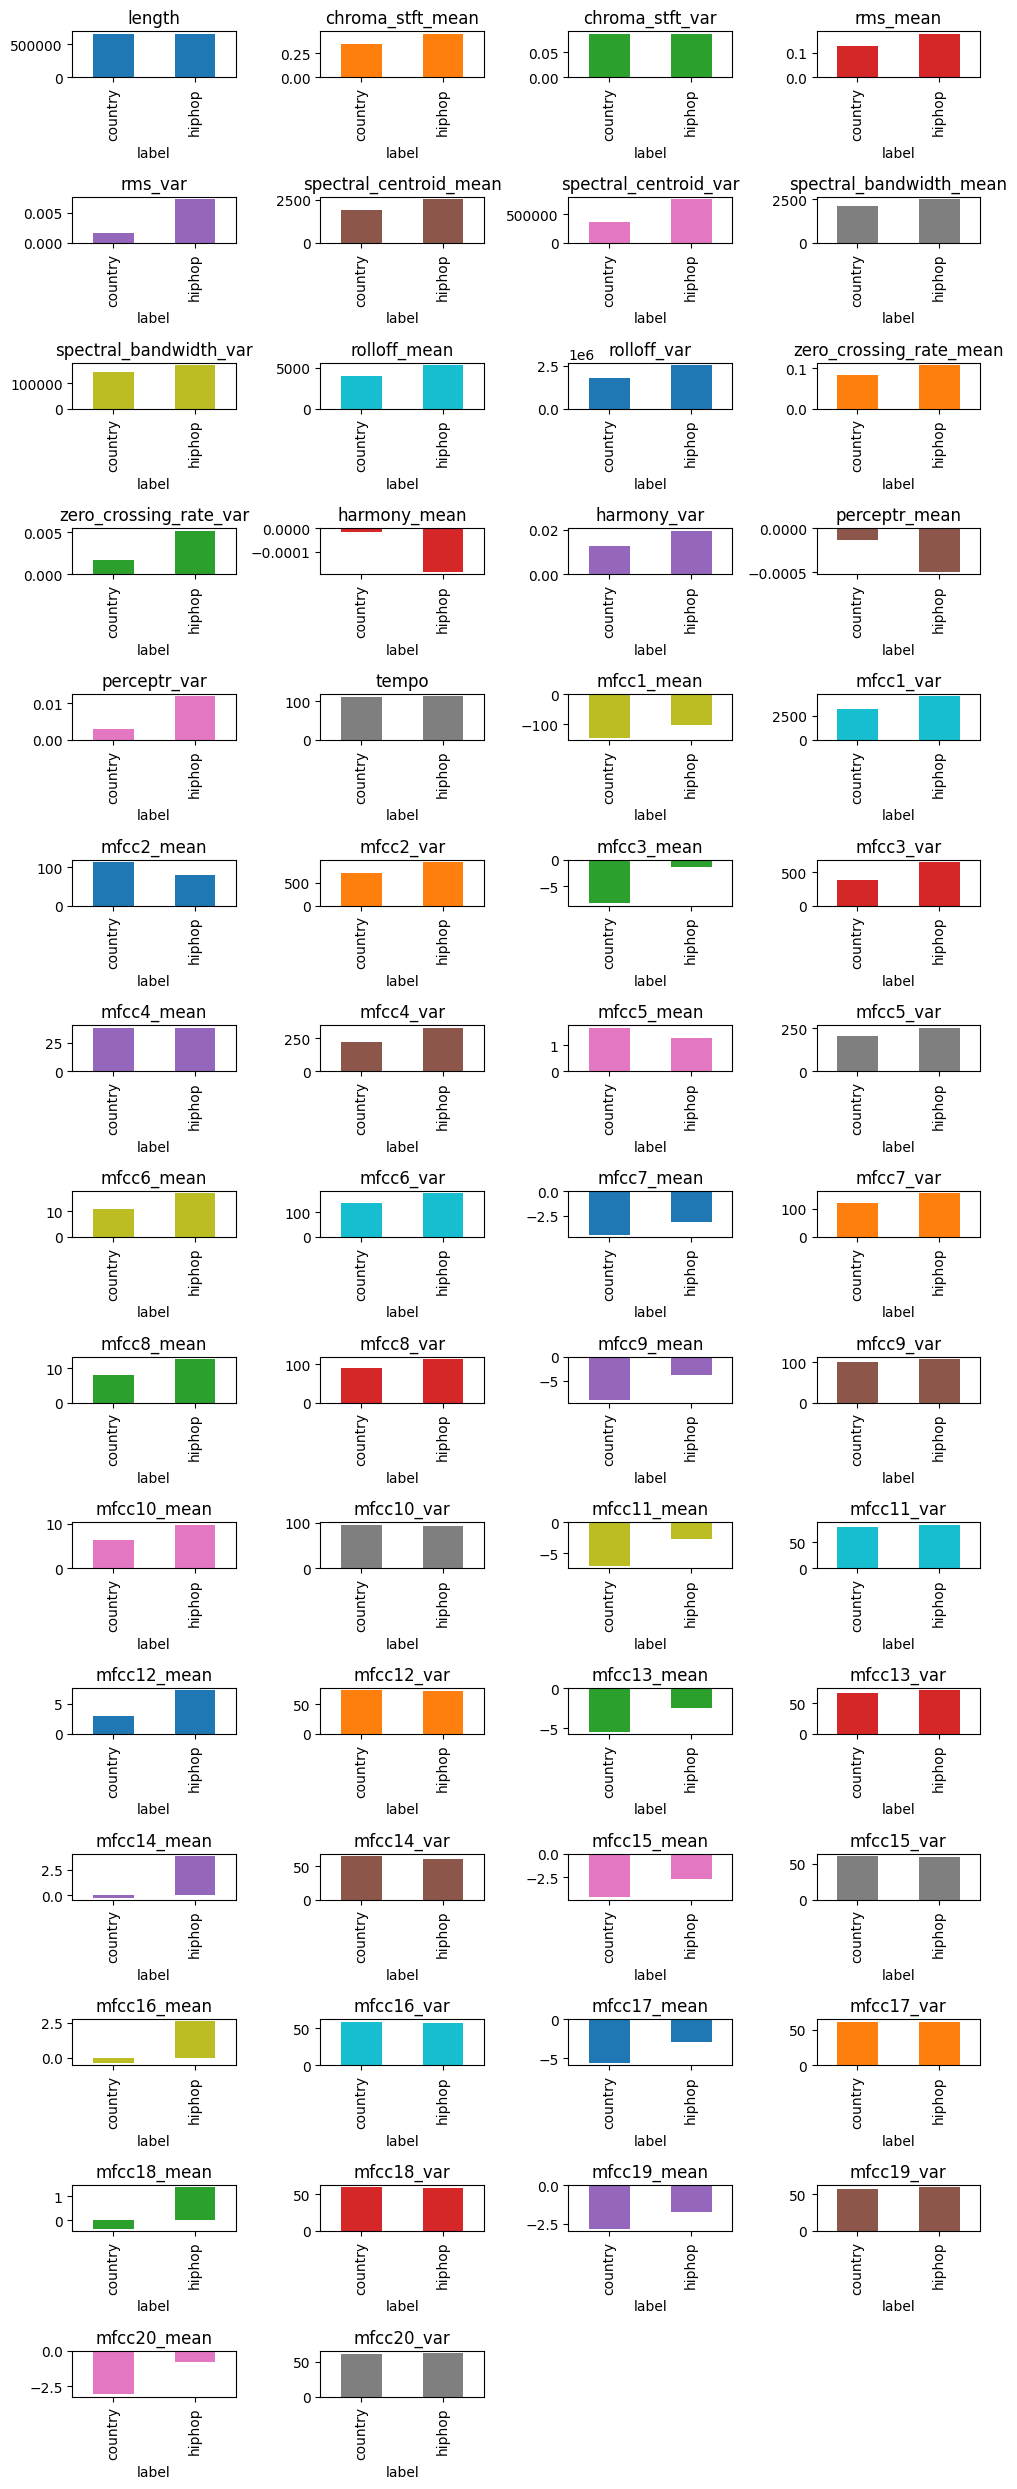

In [289]:
grouped = pd.DataFrame(df.groupby("label").mean(numeric_only=True))
cols = 4
rows = int(np.ceil(grouped.columns.size/cols))

grouped.plot.bar(figsize=(10, 25), subplots=True, layout=(rows, cols), sharex=False, xlabel=None, legend=False)
plt.tight_layout()

# From here, it looks like
# rms_mean/var, spectral_centroid_mean/var, harmony, perceptr, zcr_var, and the mfccs. of course these will have correlations.


In [290]:
# Classifying this
category = pd.get_dummies(df["label"], drop_first=True)
category

,hiphop
200,0
201,0
202,0
203,0
204,0
...,...
495,1
496,1
497,1
498,1


In [291]:
df.columns

Index(['filename', 'length', 'chroma_stft_mean', 'chroma_stft_var', 'rms_mean',
       'rms_var', 'spectral_centroid_mean', 'spectral_centroid_var',
       'spectral_bandwidth_mean', 'spectral_bandwidth_var', 'rolloff_mean',
       'rolloff_var', 'zero_crossing_rate_mean', 'zero_crossing_rate_var',
       'harmony_mean', 'harmony_var', 'perceptr_mean', 'perceptr_var', 'tempo',
       'mfcc1_mean', 'mfcc1_var', 'mfcc2_mean', 'mfcc2_var', 'mfcc3_mean',
       'mfcc3_var', 'mfcc4_mean', 'mfcc4_var', 'mfcc5_mean', 'mfcc5_var',
       'mfcc6_mean', 'mfcc6_var', 'mfcc7_mean', 'mfcc7_var', 'mfcc8_mean',
       'mfcc8_var', 'mfcc9_mean', 'mfcc9_var', 'mfcc10_mean', 'mfcc10_var',
       'mfcc11_mean', 'mfcc11_var', 'mfcc12_mean', 'mfcc12_var', 'mfcc13_mean',
       'mfcc13_var', 'mfcc14_mean', 'mfcc14_var', 'mfcc15_mean', 'mfcc15_var',
       'mfcc16_mean', 'mfcc16_var', 'mfcc17_mean', 'mfcc17_var', 'mfcc18_mean',
       'mfcc18_var', 'mfcc19_mean', 'mfcc19_var', 'mfcc20_mean', 'mfcc20_var',
  

     chroma_stft_mean  zero_crossing_rate_var  mfcc17_mean  mfcc11_mean  \
0           -0.213109               -0.554201     1.427587     0.417419   
1            0.212093               -0.837140     0.443747     0.845850   
2           -1.445690                0.155041    -0.140729    -0.240555   
3           -0.314178               -0.354324    -0.650970     0.315656   
4           -0.230761               -0.712044     1.199958     0.729492   
..                ...                     ...          ...          ...   
195          2.315223               -0.183564     0.384122    -0.288835   
196          0.364643               -0.824700     0.703184    -0.177741   
197          1.062564                0.234074    -1.409546    -1.121560   
198          1.902377                0.047522     0.544538    -0.216935   
199          0.449827                0.293423    -1.000792    -0.008193   

     mfcc14_mean  
0       0.685217  
1      -0.741748  
2      -0.041664  
3      -0.640976  
4   

<AxesSubplot: >

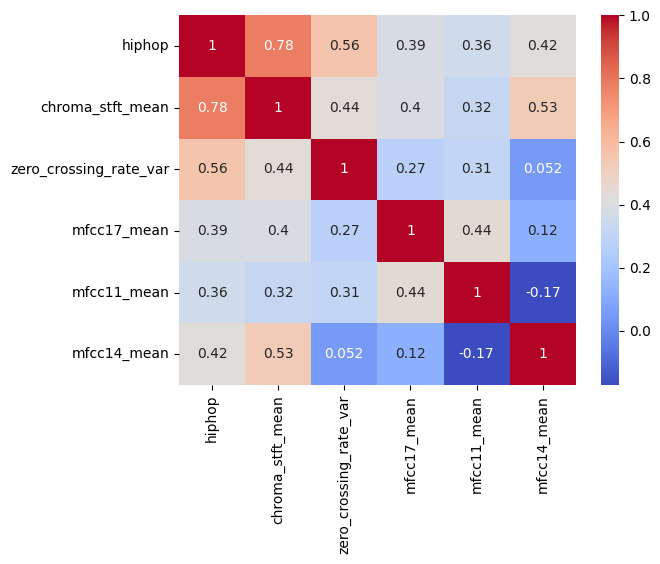

In [292]:
features = ["chroma_stft_mean", "zero_crossing_rate_var", "mfcc17_mean", "mfcc11_mean", "mfcc14_mean"]
predictors_unscaled = df[features]

# rescale predictors to avoid skewing model by largest feature
scaler = preprocessing.StandardScaler()
predictors = pd.DataFrame(scaler.fit_transform(predictors_unscaled), columns=features)
# Gotta reset index values to concatenate without Nan values.
predictors.reset_index(drop=True, inplace=True)
category.reset_index(drop=True, inplace=True)
print(predictors)
print(category)
# Verify high correlation for predictors to category
# and low correlation of predictors and themselves

feature_matrix = pd.concat([category, predictors], axis=1)
sns.heatmap(feature_matrix.corr(), annot=True, cmap='coolwarm')

### Train/Test Split

Use sklearn to split your data into testing and training sets. Remember you will need to define your categories, predictors, and test size. Use 30% test size.

In [293]:
pred_train, pred_test, cat_train, cat_test = train_test_split(predictors, category, test_size = .3)
print(cat_test)

     hiphop
170       1
100       1
101       1
75        0
133       1
50        0
80        0
53        0
10        0
113       1
156       1
23        0
61        0
98        0
162       1
166       1
84        0
152       1
97        0
31        0
8         0
195       1
4         0
198       1
141       1
161       1
18        0
9         0
15        0
168       1
196       1
42        0
102       1
38        0
19        0
139       1
7         0
142       1
73        0
138       1
155       1
190       1
126       1
55        0
160       1
49        0
129       1
82        0
147       1
60        0
178       1
65        0
112       1
154       1
106       1
70        0
184       1
90        0
172       1
128       1


### Train the Model and Evaluate (2 points)

Train the model using logistic regression.

Calculate the confusion matrix (and view as a data frame). Calculate the accuracy, precision, recall, and F1 scores.

Explain what the confusion matrix and accuracy tell us about your model.

In [294]:
model = LogisticRegression() # lbfgs is default
model.fit(pred_train, cat_train)
predictions = model.predict(pred_test)
# specifying labels just in case. Don't want to misinterpret data
cm = confusion_matrix(cat_test, predictions, labels=[0,1])
# rows of cm are truth, columns are prediction
# This is another error in the lecture.
# https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html
pd.DataFrame(cm, index=["country", "hiphop"], columns=["predicted country", "predicted hiphop"])

/usr/local/Caskroom/miniconda/base/envs/AudioTechII/lib/python3.10/site-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,predicted country,predicted hiphop
country,26,2
hiphop,7,25


In [295]:
print(classification_report(cat_test, predictions, target_names=["country", "hiphop"]))

              precision    recall  f1-score   support

     country       0.79      0.93      0.85        28
      hiphop       0.93      0.78      0.85        32

    accuracy                           0.85        60
   macro avg       0.86      0.85      0.85        60
weighted avg       0.86      0.85      0.85        60



Your model interpretation here!

- The confusion matrix shows where our model is distinguishing correctly and where it is making errors (getting confused)
- The accuracy of the model is the ratio of true predictions to total predictions. I got it in the 90s!
- Precision for each is how well the model distinguishes the positives and false positives. The high precision of country means that if my model predicts country it has a 97% chance of being right.
- Recall is how well the model captures that genre. The high recall of hiphop indicates that barely any hiphop samples were mislabelled as country. However, becuase of its lower precision, some of those hiphop predictions were actually country.
- The f1 is the harmonic mean of the precision and the recall, giving us another summary measure of accuracy.

GenAI Usage Statement:

- Tool used and date of access
- The input (prompt) you provided
- A copy of the output
- A description of how you used or edited the AI-generated content

Nope